EXPERIMENT 05 - TASK 01
Decision Tree Classification and Regression
Name    : R. Karthik
Roll No : 25EU02904


--- PART A: DECISION TREE CLASSIFICATION ---

Pima Dataset Shape: (768, 9)

First Five Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Classification Training Shape: (614, 8)
Classification Testing Shape : (154, 8)

Decision Tree Cla

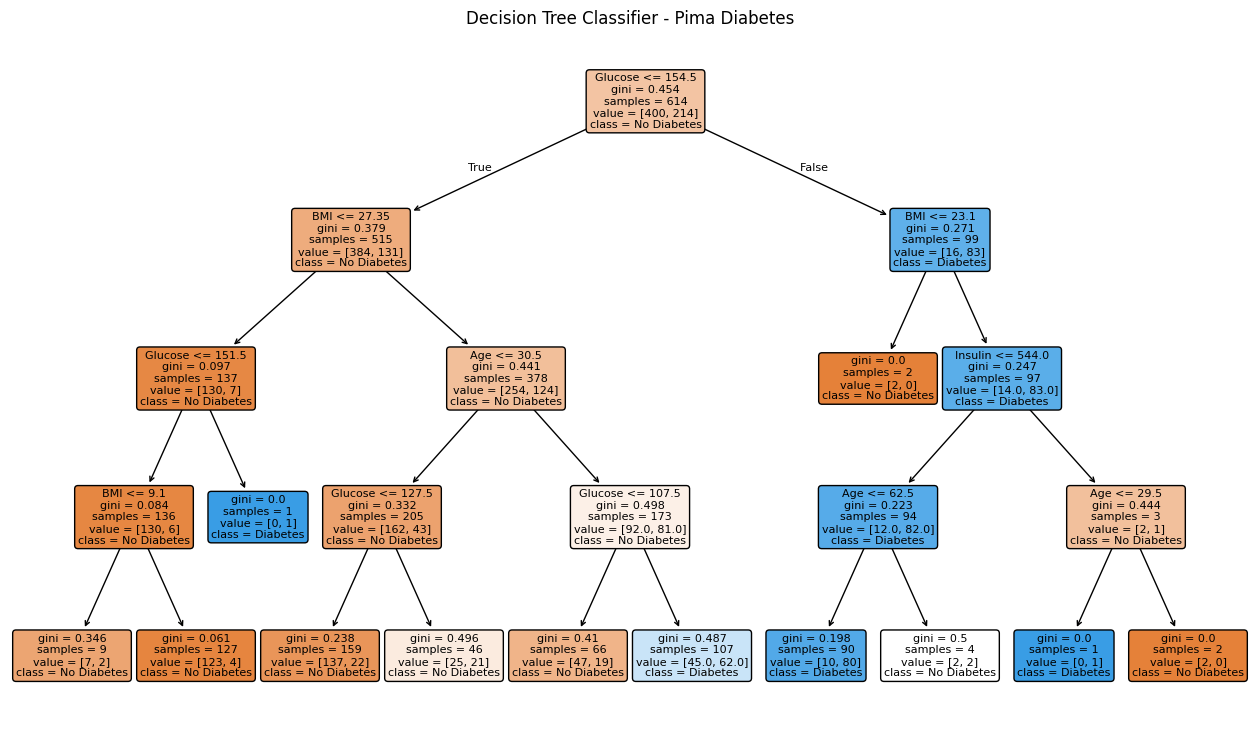



--- PART B: DECISION TREE REGRESSION ---

Boston Housing Dataset Shape:
(506, 14)

First Five Rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Decision Tree Regressor Results
--------------------------------
MSE  : 8.5539
RMSE : 2.9247
R²   : 0.8834


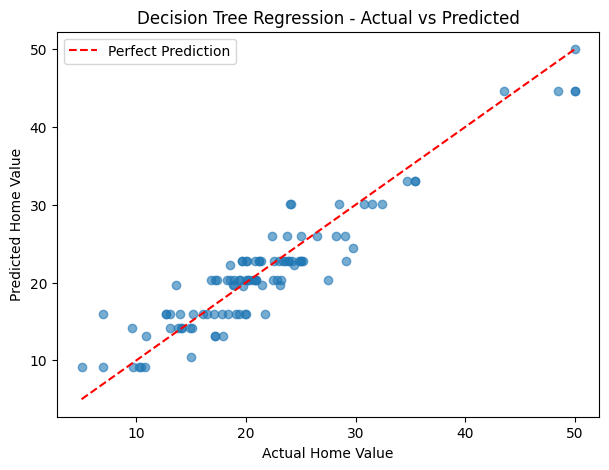


TASK 01 COMPLETED SUCCESSFULLY
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 05 - TASK 01
# Decision Tree Classification and Regression
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    r2_score
)

print("=" * 60)
print("EXPERIMENT 05 - TASK 01")
print("Decision Tree Classification and Regression")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)


# ============================================================
# PART A - DECISION TREE CLASSIFICATION
# PIMA INDIANS DIABETES DATASET
# ============================================================

print("\n\n--- PART A: DECISION TREE CLASSIFICATION ---")

pima_url = (
    "https://raw.githubusercontent.com/jbrownlee/"
    "Datasets/master/pima-indians-diabetes.data.csv"
)

pima_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

pima_df = pd.read_csv(
    pima_url,
    header=None,
    names=pima_columns
)

print("\nPima Dataset Shape:", pima_df.shape)

print("\nFirst Five Rows:")
print(pima_df.head())

# Features and target
X_pima = pima_df.drop("Outcome", axis=1)

y_pima = pima_df["Outcome"]

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima,
    y_pima,
    test_size=0.20,
    stratify=y_pima,
    random_state=42
)

print("\nClassification Training Shape:", X_train_c.shape)
print("Classification Testing Shape :", X_test_c.shape)

# Decision Tree Classifier
tree_clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_clf.fit(
    X_train_c,
    y_train_c
)

# Predictions
clf_predictions = tree_clf.predict(
    X_test_c
)

# Accuracy
clf_accuracy = accuracy_score(
    y_test_c,
    clf_predictions
)

print("\nDecision Tree Classifier Accuracy:")
print(f"{clf_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_c,
        clf_predictions,
        target_names=[
            "No Diabetes",
            "Diabetes"
        ]
    )
)

# Visualize tree
plt.figure(figsize=(16, 9))

plot_tree(
    tree_clf,
    feature_names=pima_columns[:-1],
    class_names=[
        "No Diabetes",
        "Diabetes"
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Decision Tree Classifier - Pima Diabetes"
)

plt.show()


# ============================================================
# PART B - DECISION TREE REGRESSION
# BOSTON HOUSING DATASET
# ============================================================

print("\n\n--- PART B: DECISION TREE REGRESSION ---")

boston_url = (
    "https://raw.githubusercontent.com/selva86/"
    "datasets/master/BostonHousing.csv"
)

boston_df = pd.read_csv(
    boston_url
)

print("\nBoston Housing Dataset Shape:")
print(boston_df.shape)

print("\nFirst Five Rows:")
print(boston_df.head())

# Features and target
X_boston = boston_df.drop(
    "medv",
    axis=1
)

y_boston = boston_df["medv"]

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_boston,
    y_boston,
    test_size=0.20,
    random_state=42
)

# Standardization
scaler = StandardScaler()

X_train_r_scaled = scaler.fit_transform(
    X_train_r
)

X_test_r_scaled = scaler.transform(
    X_test_r
)

# Decision Tree Regressor
tree_reg = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_reg.fit(
    X_train_r_scaled,
    y_train_r
)

# Predictions
reg_predictions = tree_reg.predict(
    X_test_r_scaled
)

# Metrics
mse = mean_squared_error(
    y_test_r,
    reg_predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_r,
    reg_predictions
)

print("\nDecision Tree Regressor Results")
print("--------------------------------")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Actual vs Predicted
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_r,
    reg_predictions,
    alpha=0.6
)

plt.plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()],
    "r--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Home Value")
plt.ylabel("Predicted Home Value")

plt.title(
    "Decision Tree Regression - Actual vs Predicted"
)

plt.legend()

plt.show()


# ============================================================
# CONCLUSION
# ============================================================

print("\n" + "=" * 60)
print("TASK 01 COMPLETED SUCCESSFULLY")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)